В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random
from timeit import default_timer as timer
from tqdm.auto import tqdm

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

***3 галузі, де сьогодні використовується комп'ютерний зір:***

1. **Автомобільна промисловість (безпілотні авто, напр. Tesla)** — виявлення пішоходів, інших авто, дорожніх знаків та розмітки в реальному часі для автономного керування.
2. **Медицина / охорона здоров'я** — аналіз медичних знімків (рентген, МРТ, КТ), автоматичне виявлення пухлин, переломів та інших патологій на зображеннях.
3. **Роздрібна торгівля (ритейл)** — каси без касирів (Amazon Go), розпізнавання товарів на полицях, контроль наявності запасів та аналіз поведінки покупців.

***Інші приклади:*** сільське господарство (моніторинг посівів з дронів), безпека/відеонагляд (розпізнавання облич), виробництво (контроль якості деталей на конвеєрі).

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

<div style="display: flex; gap: 2%;">
    <img src="attachments/IMG_3614.jpeg" width="49%">
    <img src="attachments/task_2.png" width="49%">
</div>

***Висновки:***

1. **Мережа правильно розпізнала об'єкт.** Я завантажила власне фото піци, і на виході (output) клас pizza отримав найвищий score серед усіх 10 класів. Це показує, що навіть проста CNN може правильно класифікувати реальний об’єкт, незважаючи на ракурс, освітлення та сторонні деталі на фоні.

2. **Зображення розкладається на канали й проходить через послідовність шарів.** Зображення спочатку розділяється на три кольорові канали (RGB), після чого проходить через кілька згорткових шарів. На ранніх шарах модель знаходить прості ознаки (контури, краї, текстури), а на глибших — більш складні комбінації ознак. Червоні та сині області показують, наскільки сильно різні фільтри реагують на окремі ділянки зображення.

3. **Між згортками працюють ReLU та MaxPool.** Між згортковими шарами працюють ReLU та MaxPool. ReLU додає нелінійність, зануляючи всі від’ємні значення, а MaxPool зменшує розмір карт ознак. Завдяки цьому мережа поступово переходить від аналізу дрібних деталей до розпізнавання всього об’єкта.

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [2]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [3]:
# Кількість елементів у кожному наборі
print(f"Навчальних зразків: {len(train_data)}")
print(f"Тестових зразків:   {len(test_data)}")

Навчальних зразків: 60000
Тестових зразків:   10000


In [4]:
# Формат (розмірності) однієї картинки
image, label = train_data[0]
print(f"Формат зображення: {image.shape}") # (кольорові канали, висота, ширина)
print(f"Мітка першого зразка: {label}")

Формат зображення: torch.Size([1, 28, 28])
Мітка першого зразка: 5


In [5]:
# Класи, представлені в наборі даних
class_names = train_data.classes
print(f"Кількість класів: {len(class_names)}")
print(f"Класи: {class_names}")

Кількість класів: 10
Класи: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

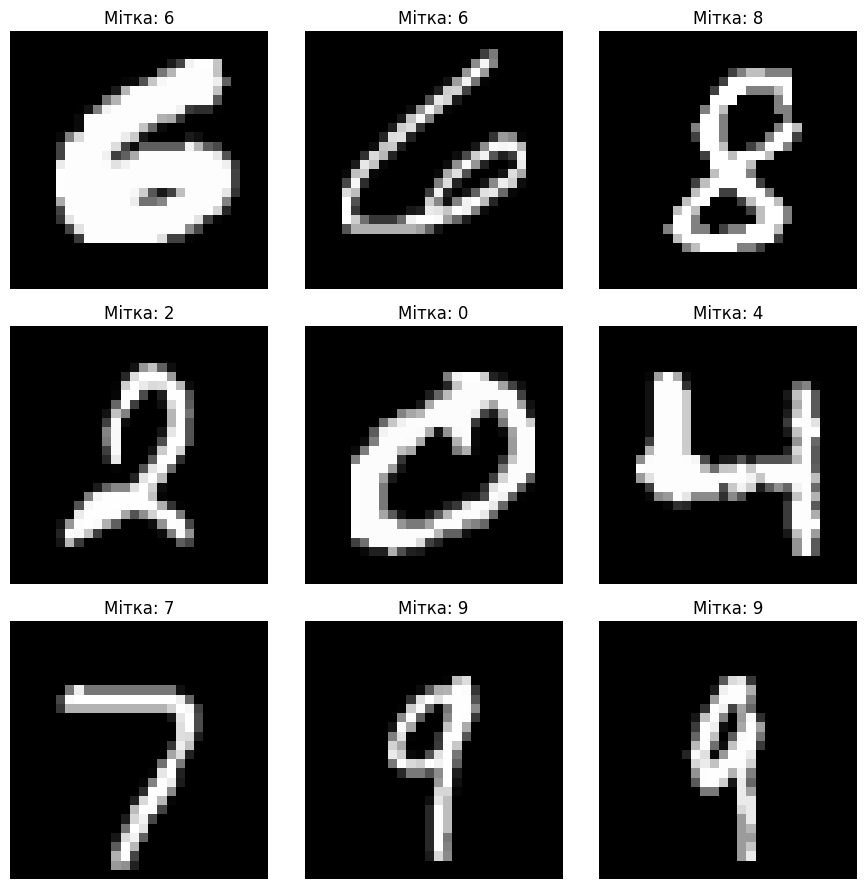

In [6]:
# Візуалізуємо 9 випадкових зразків у вигляді сітки 3x3
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 3, 3

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Мітка: {label}")
    plt.axis(False)
plt.tight_layout()
plt.show()

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [7]:
BATCH_SIZE = 32

# Перетворюємо датасети у data loaders
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Батчів у train_dataloader: {len(train_dataloader)} (по {BATCH_SIZE} зразків)")
print(f"Батчів у test_dataloader:  {len(test_dataloader)} (по {BATCH_SIZE} зразків)")

Батчів у train_dataloader: 1875 (по 32 зразків)
Батчів у test_dataloader:  313 (по 32 зразків)


In [8]:
# Форма даних, яку повертає дата лоадер
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Форма батчу ознак: {train_features_batch.shape}  -> [batch_size, канали, висота, ширина]")
print(f"Форма батчу міток: {train_labels_batch.shape}  -> [batch_size]")

Форма батчу ознак: torch.Size([32, 1, 28, 28])  -> [batch_size, канали, висота, ширина]
Форма батчу міток: torch.Size([32])  -> [batch_size]


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [9]:
class MNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # після двох MaxPool(2) зображення 28x28 стало 7x7, тому in_features = hidden_units * 7 * 7
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [10]:
torch.manual_seed(42)
model_test = MNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names))
print(model_test)

# Перевіримо, що модель приймає зображення MNIST і повертає 10 логітів
dummy = torch.randn(1, 1, 28, 28)
print(f"\nФорма виходу для одного зображення: {model_test(dummy).shape}  -> [1, 10]")

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

Форма виходу для одного зображення: torch.Size([1, 10])  -> [1, 10]


## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [11]:
# На Mac з Apple Silicon прискорювачем є MPS, на Nvidia - CUDA, інакше - CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"PyTorch version: {torch.__version__}")
print(f"Пристрій за замовчуванням: {device}")

PyTorch version: 2.11.0
Пристрій за замовчуванням: mps


In [12]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def print_train_time(start, end, device=None):
    total_time = end - start
    print(f"Час навчання на {device}: {total_time:.3f} секунд")
    return total_time

In [13]:
def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device):
    train_loss, train_acc = 0, 0
    model.train()
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)                                   
        loss = loss_fn(y_pred, y)                           
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()                              
        loss.backward()                                   
        optimizer.step()                             
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(model, data_loader, loss_fn, accuracy_fn, device):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [14]:
def train_model_on_device(target_device, epochs=5):
    torch.manual_seed(42)
    model = MNISTModelV2(input_shape=1, hidden_units=10,
                         output_shape=len(class_names)).to(target_device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    print(f"===== Навчання на пристрої: {target_device.upper()} =====")
    start = timer()
    for epoch in tqdm(range(epochs)):
        print(f"Епоха: {epoch}\n-------")
        train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn, target_device)
        test_step(model, test_dataloader, loss_fn, accuracy_fn, target_device)
    end = timer()
    total_time = print_train_time(start, end, target_device)
    return model, total_time

In [15]:
# Навчання на CPU
model_cpu, time_cpu = train_model_on_device("cpu", epochs=5)

===== Навчання на пристрої: CPU =====


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
-------
Train loss: 0.26523 | Train accuracy: 91.34%
Test loss: 0.07626 | Test accuracy: 97.55%

Епоха: 1
-------
Train loss: 0.06746 | Train accuracy: 97.89%
Test loss: 0.04091 | Test accuracy: 98.62%

Епоха: 2
-------
Train loss: 0.05327 | Train accuracy: 98.38%
Test loss: 0.04382 | Test accuracy: 98.64%

Епоха: 3
-------
Train loss: 0.04383 | Train accuracy: 98.58%
Test loss: 0.04430 | Test accuracy: 98.61%

Епоха: 4
-------
Train loss: 0.03848 | Train accuracy: 98.77%
Test loss: 0.03109 | Test accuracy: 98.93%

Час навчання на cpu: 100.723 секунд


In [16]:
# Навчання на GPU (MPS на Apple Silicon / CUDA на Nvidia)
if device != "cpu":
    model_gpu, time_gpu = train_model_on_device(device, epochs=5)
    print("\n===== Порівняння часу навчання за 5 епох =====")
    print(f"CPU:          {time_cpu:.2f} с")
    print(f"GPU ({device}): {time_gpu:.2f} с")
    print(f"Прискорення:  x{time_cpu / time_gpu:.2f}")
    model = model_gpu
else:
    print("GPU недоступний — навчання виконано лише на CPU.")
    model = model_cpu

===== Навчання на пристрої: MPS =====


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
-------
Train loss: 0.26314 | Train accuracy: 91.36%
Test loss: 0.06722 | Test accuracy: 97.79%

Епоха: 1
-------
Train loss: 0.06723 | Train accuracy: 97.88%
Test loss: 0.04253 | Test accuracy: 98.49%

Епоха: 2
-------
Train loss: 0.05286 | Train accuracy: 98.36%
Test loss: 0.04476 | Test accuracy: 98.47%

Епоха: 3
-------
Train loss: 0.04391 | Train accuracy: 98.61%
Test loss: 0.04294 | Test accuracy: 98.62%

Епоха: 4
-------
Train loss: 0.03862 | Train accuracy: 98.78%
Test loss: 0.03437 | Test accuracy: 98.89%

Час навчання на mps: 47.184 секунд

===== Порівняння часу навчання за 5 епох =====
CPU:          100.72 с
GPU (mps): 47.18 с
Прискорення:  x2.13


Модель була навчена протягом 5 епох на CPU та GPU Apple Silicon через MPS. На CPU виконання зайняло 100.72 секунди, а на MPS — 47.18 секунди, тобто GPU забезпечив прискорення приблизно у 2.13 раза. Точність на тестовому наборі майже не відрізнялася: 98.93% на CPU і 98.89% на MPS. Отже, використання MPS суттєво скоротило час обчислень без помітної втрати якості моделі.

## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [17]:
def make_predictions(model, data, device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)  # додаємо вимір батчу
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)  # логіт -> ймовірність
            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)

In [18]:
# Беремо 9 випадкових зразків з тестового набору
random.seed(42)
test_samples, test_labels = [], []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# Робимо прогнози
pred_probs = make_predictions(model, test_samples, device)
pred_classes = pred_probs.argmax(dim=1)
print(f"Прогнозовані класи: {pred_classes}")
print(f"Істинні мітки:      {torch.tensor(test_labels)}")

Прогнозовані класи: tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])
Істинні мітки:      tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])


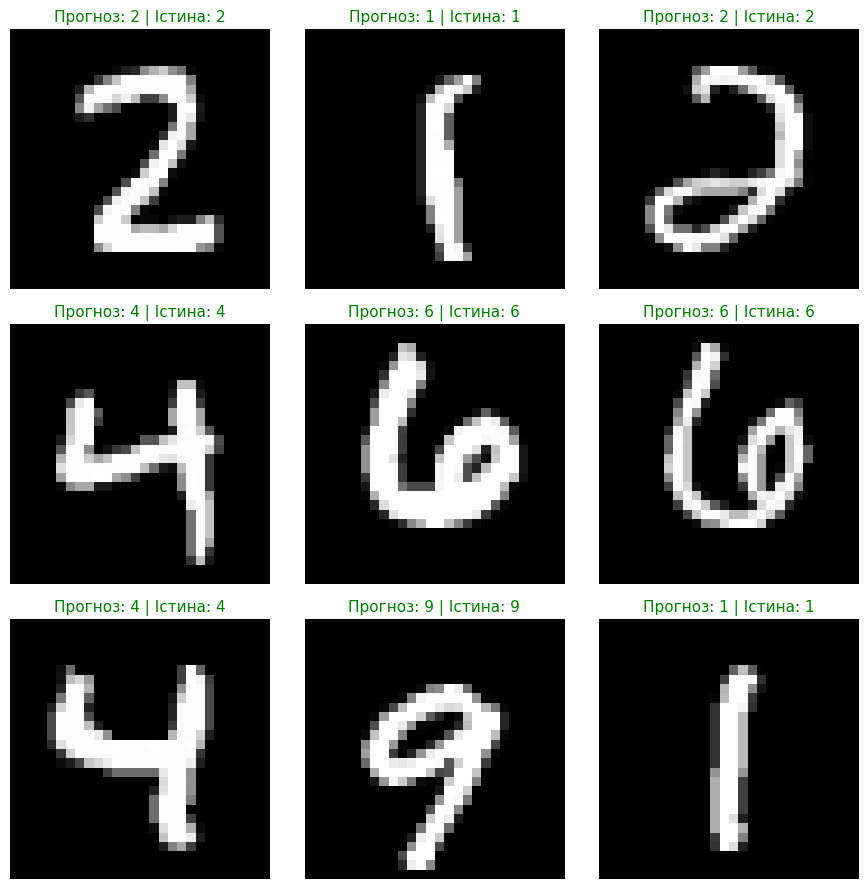

In [19]:
# Візуалізація: зелений заголовок - правильний прогноз, червоний - помилка
plt.figure(figsize=(9, 9))
for i, sample in enumerate(test_samples):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")
    pred_label = pred_classes[i].item()
    truth_label = test_labels[i]
    title = f"Прогноз: {pred_label} | Істина: {truth_label}"
    plt.title(title, fontsize=11, c="g" if pred_label == truth_label else "r")
    plt.axis(False)
plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [20]:
# Робимо прогнози по всьому тестовому набору
y_preds = []
model.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Робимо прогнози"):
        X, y = X.to(device), y.to(device)
        y_logit = model(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

Робимо прогнози:   0%|          | 0/313 [00:00<?, ?it/s]

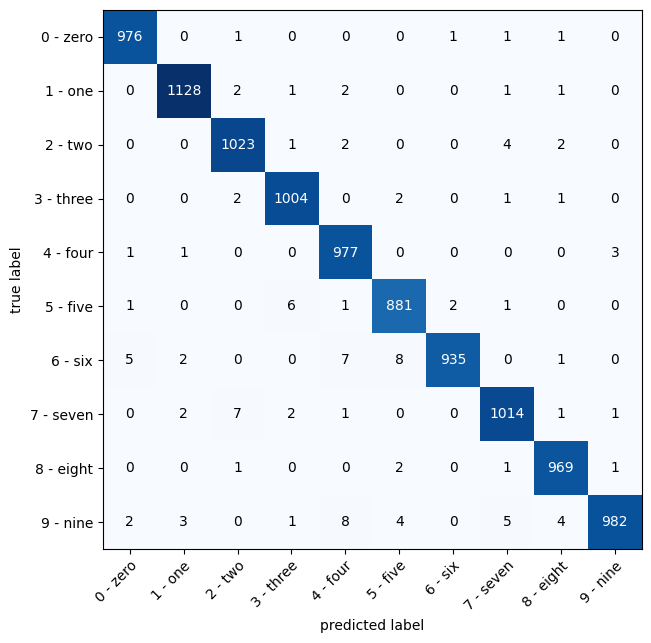

In [21]:
# Матриця плутанини
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)
plt.show()

Більшість передбачень знаходяться на головній діагоналі матриці, що свідчить про високу якість класифікації та правильне розпізнавання більшості цифр. Помилки виникають переважно між візуально схожими цифрами. Наприклад, цифра 5 іноді класифікується як 3, 6 — як 5, 7 — як 2, а 9 — як 4. Найкраще модель розпізнає цифри 0, 1, 2 та 3, тоді як найбільше труднощів виникає з цифрами 5, 6, 7 та 9, хоча кількість таких помилок залишається дуже невеликою.

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

Всього помилок: 111 з 10000 (1.11%)


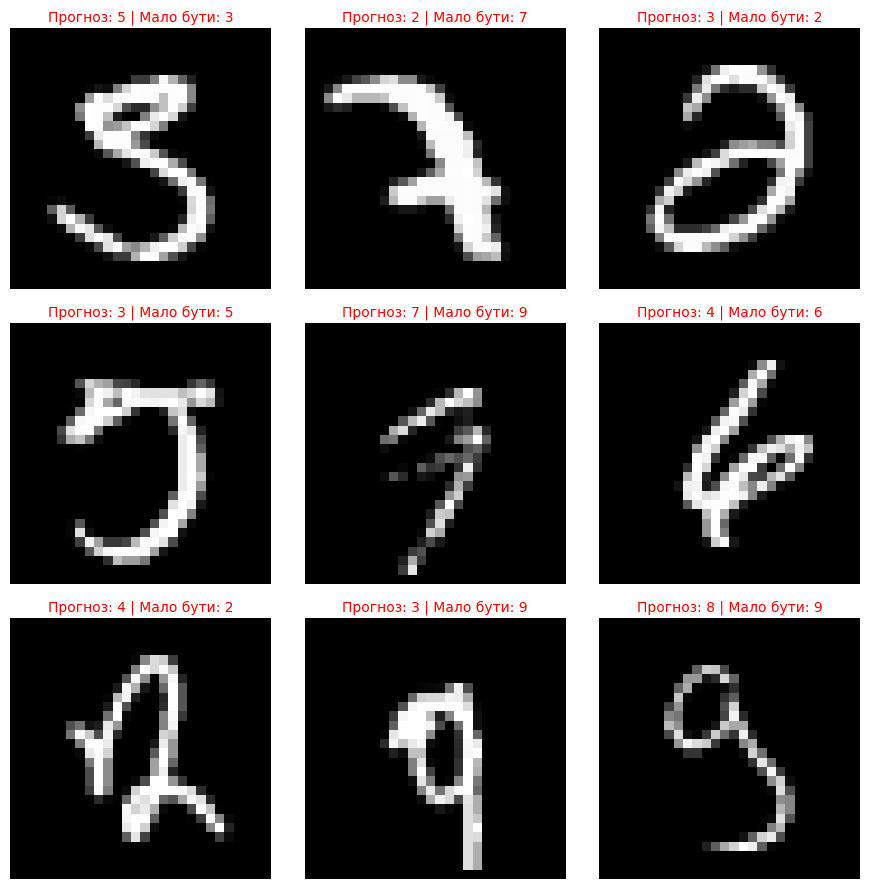

In [22]:
# Знаходимо індекси, де прогноз не збігається з істинною міткою
test_targets = test_data.targets
wrong_idx = torch.where(y_pred_tensor != test_targets)[0]
print(f"Всього помилок: {len(wrong_idx)} з {len(test_targets)} "
      f"({len(wrong_idx) / len(test_targets) * 100:.2f}%)")

# Обираємо 9 випадкових помилкових прогнозів
torch.manual_seed(42)
sample_wrong = wrong_idx[torch.randperm(len(wrong_idx))[:9]]

plt.figure(figsize=(9, 9))
for i, idx in enumerate(sample_wrong):
    img, true_label = test_data[idx]
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    pred_label = y_pred_tensor[idx].item()
    plt.title(f"Прогноз: {pred_label} | Мало бути: {true_label}", fontsize=10, c="r")
    plt.axis(False)
plt.tight_layout()
plt.show()

***Висновки:***

Загальна частка помилок досить мала (~1–2%). Якщо переглянути помилкові приклади, видно, що це переважно помилка даних, а не моделювання: у більшості випадків цифри написані нерозбірливо або двозначно — так, що навіть людині важко однозначно сказати, що це за цифра.

Модель уже досягла дуже високої точності, тому подальше суттєве покращення обмежене саме якістю самих зображень. Невелику частину помилок можна прибрати кращою архітектурою чи довшим навчанням, але в даному випадку стелю точності на MNIST здебільшого визначає неоднозначність рукописного почерку.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [23]:
# Створюємо випадковий тензор форми [1, 3, 64, 64]
torch.manual_seed(42)
random_tensor = torch.randn(size=(1, 3, 64, 64))
print(f"Форма вхідного тензора: {random_tensor.shape}\n")

# Пропускаємо через Conv2d з різними kernel_size (stride=1, padding=0)
print("Вплив kernel_size на вихідну форму (stride=1, padding=0):")
for k in [1, 3, 5, 7, 9]:
    conv_layer = nn.Conv2d(in_channels=3, out_channels=10,
                           kernel_size=k, stride=1, padding=0)
    output = conv_layer(random_tensor)
    h = output.shape[-1]
    print(f"  kernel_size={k}:  вихід {tuple(output.shape)}  -> просторовий розмір {h}x{h}")

Форма вхідного тензора: torch.Size([1, 3, 64, 64])

Вплив kernel_size на вихідну форму (stride=1, padding=0):
  kernel_size=1:  вихід (1, 10, 64, 64)  -> просторовий розмір 64x64
  kernel_size=3:  вихід (1, 10, 62, 62)  -> просторовий розмір 62x62
  kernel_size=5:  вихід (1, 10, 60, 60)  -> просторовий розмір 60x60
  kernel_size=7:  вихід (1, 10, 58, 58)  -> просторовий розмір 58x58
  kernel_size=9:  вихід (1, 10, 56, 56)  -> просторовий розмір 56x56


In [24]:
# Додатково подивимось на вплив stride та padding при фіксованому kernel_size=3
print("Вплив stride та padding (kernel_size=3):")
for stride, padding in [(1, 0), (1, 1), (2, 0), (2, 1)]:
    conv_layer = nn.Conv2d(in_channels=3, out_channels=10,
                           kernel_size=3, stride=stride, padding=padding)
    output = conv_layer(random_tensor)
    h = output.shape[-1]
    print(f"  stride={stride}, padding={padding}:  вихід {tuple(output.shape)}  -> {h}x{h}")

Вплив stride та padding (kernel_size=3):
  stride=1, padding=0:  вихід (1, 10, 62, 62)  -> 62x62
  stride=1, padding=1:  вихід (1, 10, 64, 64)  -> 64x64
  stride=2, padding=0:  вихід (1, 10, 31, 31)  -> 31x31
  stride=2, padding=1:  вихід (1, 10, 32, 32)  -> 32x32


***Висновок:***

Під час експерименту видно, що параметр `kernel_size` безпосередньо впливає на розмір вихідної карти ознак. При збільшенні `kernel_size` просторові розміри вихідного тензора зменшуються (за незмінних `stride=1` і `padding=0`), оскільки згорткове ядро охоплює більшу область зображення. Водночас більший фільтр дозволяє аналізувати більш глобальні патерни, але потребує більшої кількості обчислень.

Додатково було перевірено вплив параметрів `stride` та `padding`. Збільшення `stride` зменшує розмір вихідної карти ознак, а використання `padding` дозволяє зберегти просторові розміри вхідного зображення. Наприклад, при `kernel_size=3`, `stride=1` і `padding=1` вихідний тензор має той самий розмір `64×64`, що й вхідний.

Отже, параметри `kernel_size`, `stride` та `padding` визначають, яку інформацію буде захоплювати згортковий шар і яким буде розмір його виходу, тому їх правильний вибір є важливою складовою проєктування згорткових нейронних мереж.